# PyTorch implementation of an $m$-dimensional Fourier Learning Machine

FLM is composed of a number of fully connected, single hidden-layer neural networks called sub-networks. Each sub-network corresponds to a learnable frequency vector $\boldsymbol{n} \in \mathbb{R}^m$ and contains $l=2^{m-1}$ cosine-activated hidden neurons. The output of the subnetwork associated with frequency vector $\boldsymbol{n}$ is


$$ H_{\boldsymbol{n}}(\boldsymbol{x}) \;=\; \sum_{i=1}^{l} A_i^{(\boldsymbol{n})}\,
\cos\!\big((\boldsymbol{e}^{(i)}\odot\boldsymbol{n})\cdot\boldsymbol{x}-\phi_i^{(\boldsymbol{n})}\big).$$

The sign vector $\boldsymbol{e}^{(i)} \in \{1, -1\}^m$ is the $i$-th row of the **$m$-Lexi Sign Matrix** $S^{(m)}$, which is
fixed, not trainable. As the input-to-hidden weights, each of the $l$ neurons within a sub-network use the same frequency vector $\boldsymbol{n}$ by uniquely flipping the signs of its elements. In other words, the input to $i$-th hidden neuron weight vector is the elementwise product $(\boldsymbol{e}^{(i)}\odot\boldsymbol{n})$. The output of an FLM with $N$ sub-networks is the ordinary sum of the outputs of the $N$ subnetwork.

$$\widehat{f}(\boldsymbol{x}) \;=\; \sum_{\boldsymbol{n}\in\mathcal{N}} H_{\boldsymbol{n}}(\boldsymbol{x}),$$

where $\mathcal{N}$ is a collection of $N$ frequency vectors.

In [1]:
import math
from itertools import product

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

## Create the Lexi-Sign Matrix

**$m$-Lexi Sign Matrix $S^{(m)}$**: It is an $l\times m$ matrix with
$l=2^{m-1}$ rows. The first column is fixed to $+1$; the remaining $m-1$ columns range over all
of $\{+1,-1\}^{m-1}$ in lexicographic order (with $+1$ ahead of $-1$). For example, for $m = 2$ and $m = 3$,

$$
S^{(2)} =
\begin{bmatrix}
1 &  1 \\
1 & -1 \\
\end{bmatrix}, \quad
S^{(3)} =
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & -1 \\
1 & -1 & 1 \\
1 & -1 & -1
\end{bmatrix}
$$

In [5]:
def lexi_sign_matrix(m: int) -> torch.Tensor:
    """Return S^(m): shape (2**(m-1), m). First column +1; the rest over {+1,-1}^(m-1)."""
    tail = list(product([1, -1], repeat=m - 1))   # yields +1 before -1 -> lexicographic
    rows = [(1,) + t for t in tail]
    return torch.tensor(rows, dtype=torch.get_default_dtype())

# quick look
print("S^(3) =\n", lexi_sign_matrix(3))

S^(3) =
 tensor([[ 1.,  1.,  1.],
        [ 1.,  1., -1.],
        [ 1., -1.,  1.],
        [ 1., -1., -1.]])


## Frequency initialization
**Default frequency initialisation.** Integer lattice points in $\mathbb{N}_0^m$, taken in order of
increasing Euclidean norm (low frequencies first), with a lexicographic tie-break. For $m=2$ this
reproduces $(0,0),(0,1),(1,0),(1,1),\dots$.

In [33]:
def lattice_frequencies(N: int, m: int) -> torch.Tensor:
    """First N points of N_0^m ordered by (Euclidean norm, then lexicographically). Shape (N, m)."""
    K = 1
    while True:
        pts = list(product(range(K + 1), repeat=m))          # {0,...,K}^m
        # points with norm <= K are guaranteed complete (anything excluded has a coord > K)
        pts = [p for p in pts if sum(c * c for c in p) <= K * K]
        if len(pts) >= N:
            pts.sort(key=lambda p: (sum(c * c for c in p), p))
            return torch.tensor(pts[:N], dtype=torch.get_default_dtype())
        K += 1

# quick look
print("frequencies (m=2, N=4) =\n", lattice_frequencies(4, 2))

frequencies (m=2, N=4) =
 tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])


## The FLM module

**Wight Initialisation** follows the paper: frequencies on the integer lattice, phases $\sim N(0,\pi/3)$,
amplitudes $= 0$. With zero amplitudes the output starts at exactly $0$, and on the first step only
the amplitudes receive gradient (frequency/phase gradients are proportional to the amplitudes), so
frequencies move slowly early on. The parameter initialization heavily depends on the function its approximating (the application), 
so we strongly encourage trying different weight initializations based on the applications.

In [7]:
class FourierLearningMachine(nn.Module):
    """Arguments:
        m: input dimension.
        N: network size = number of sub-networks (frequency vectors).
        seed: optional int for reproducible phase initialisation.

    NN Input:  x of shape (m,), a single point assumed scaled to [-pi, pi]^m.
    NN Output: scalar f(x).

    To evaluate on a batch X of shape (B, m), use torch.vmap(model)(X) -> shape (B,).
    """

    def __init__(self, m: int, N: int, seed: int | None = None):
        super().__init__()
        self.m = m
        self.N = N
        self.l = 2 ** (m - 1)     # hidden neurons per sub-network

        if seed is not None:
            torch.manual_seed(seed)

        # Fixed sign structure S^(m) (NOT trainable)
        self.register_buffer("sign_matrix", lexi_sign_matrix(m))     # size --> (l, m)

        # Trainable parameters (initialization)
        self.frequencies = nn.Parameter(lattice_frequencies(N, m))            # size --> (N, m)
        self.phases      = nn.Parameter(torch.randn(N, self.l) * (math.pi / 3))  # size --> (N, l)
        self.amplitudes  = nn.Parameter(torch.zeros(N, self.l))               # size --> (N, l)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        W = self.frequencies.unsqueeze(1) * self.sign_matrix     # size --> (N, l, m) | e^(i) ⊙ n
        z = W @ x - self.phases                                  # size --> (N, l)    | (e^(i) ⊙ n)·x - phi
        H = (self.amplitudes * torch.cos(z)).sum(dim=1)          # size --> (N,)      | H_n = sum_i A_i cos(...)
        return H.sum()                                           # scalar             | f = sum_n H_n

### 3. Input scaling (recommended, left to the user)
If your input data lives on some box $[a_j,b_j]$ per dimension, we recommend the simple affine map
below to the reference domain $[-\pi,\pi]^m$ before calling the model.

In [8]:
def to_reference_domain(x: torch.Tensor, lows, highs) -> torch.Tensor:
    """Affinely map x from the box [lows, highs] (per dimension) onto [-pi, pi]^m."""
    lows  = torch.as_tensor(lows,  dtype=x.dtype, device=x.device)
    highs = torch.as_tensor(highs, dtype=x.dtype, device=x.device)
    return (x - lows) / (highs - lows) * (2 * math.pi) - math.pi

# 4. Demo: approximating a very simple 2D function

Target on $[-\pi,\pi]^2$:

$$g(x_1,x_2) = \sin(1.5\,x_1)\,\cos(\pi\,x_2).$$

The frequencies are deliberately **non-integer**, so this cannot be captured by a classical
(integer-frequency) Fourier series with a few modes — the FLM has to *learn* the frequencies.

**Batch evaluation.** The FLM is defined per point, so we apply it to a whole set of points with
`torch.vmap(model)`, which maps the single-input forward over the rows of `X` and returns one output
per point. The architecture stays untouched.

**Sampling.** The **training set** is drawn uniformly at random from the domain $[-\pi,\pi]^2$;
the **test set** is an evenly spaced grid over the same domain.

In [9]:
# --- test set: an evenly spaced grid on [-pi, pi]^2 ---
n_side = 40
grid = torch.linspace(-math.pi, math.pi, n_side)
Xg, Yg = torch.meshgrid(grid, grid, indexing="ij")
X_test = torch.stack([Xg.reshape(-1), Yg.reshape(-1)], dim=1)     # (n_side^2, 2)

# --- training set: points sampled uniformly at random from [-pi, pi]^2 ---
n_train = 1000
torch.manual_seed(0)                                             # reproducible sampling
X_train = torch.rand(n_train, 2) * (2 * math.pi) - math.pi        # (n_train, 2)

def target_fn(x):
    return torch.sin(1.5 * x[:, 0]) * torch.cos(torch.pi * x[:, 1])   # shape (len(x),)

y_train = target_fn(X_train)
y_test  = target_fn(X_test)
print("train:", tuple(X_train.shape), "  test:", tuple(X_test.shape))

train: (1000, 2)   test: (1600, 2)


In [38]:
# --- model + training ---
model = FourierLearningMachine(m=2, N=16, seed=0)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, betas=(0.9, 0.9999))

def flm_on_batch(X):
    """Apply the single-input FLM to every row of X -> shape (len(X),)."""
    return torch.vmap(model)(X)

epochs = 5000
train_hist, test_hist = [], []
for epoch in range(epochs):
    optimizer.zero_grad()
    train_loss = ((flm_on_batch(X_train) - y_train) ** 2).mean()
    train_loss.backward()
    optimizer.step()

    train_hist.append(train_loss.item())
    with torch.no_grad():
        test_hist.append(((flm_on_batch(X_test) - y_test) ** 2).mean().item())

    if (epoch + 1) % 500 == 0:
        print(f"epoch {epoch + 1:5d}   train MSE {train_hist[-1]:.3e}   test MSE {test_hist[-1]:.3e}")

print(f"\nfinal train MSE: {train_hist[-1]:.3e}   |   final test MSE: {test_hist[-1]:.3e}")

epoch   500   train MSE 9.189e-02   test MSE 1.000e-01
epoch  1000   train MSE 1.720e-02   test MSE 1.909e-02
epoch  1500   train MSE 3.397e-04   test MSE 3.910e-04
epoch  2000   train MSE 2.301e-06   test MSE 3.092e-06
epoch  2500   train MSE 1.740e-07   test MSE 2.518e-07
epoch  3000   train MSE 3.314e-08   test MSE 4.680e-08
epoch  3500   train MSE 5.517e-09   test MSE 7.761e-09
epoch  4000   train MSE 7.919e-10   test MSE 1.116e-09
epoch  4500   train MSE 1.069e-10   test MSE 1.502e-10
epoch  5000   train MSE 1.812e-11   test MSE 2.421e-11

final train MSE: 1.812e-11   |   final test MSE: 2.421e-11


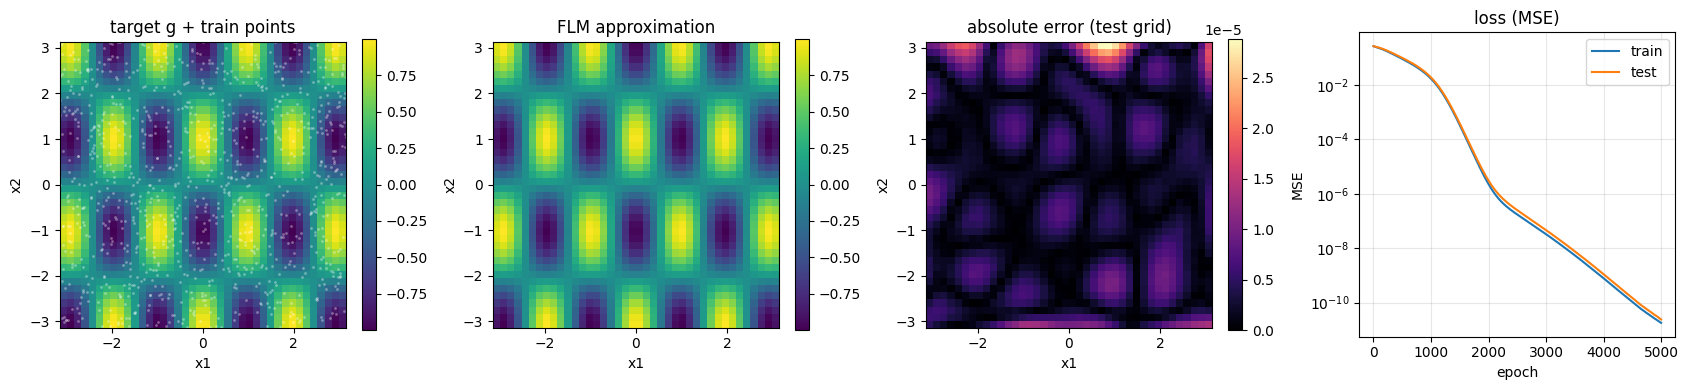

In [41]:
# --- visualise truth vs FLM vs error (on the evenly spaced test grid) + loss curves ---
with torch.no_grad():
    pred = flm_on_batch(X_test)

T = y_test.reshape(n_side, n_side).numpy()
P = pred.reshape(n_side, n_side).numpy()
E = np.abs(T - P)
extent = [-math.pi, math.pi, -math.pi, math.pi]

fig, ax = plt.subplots(1, 4, figsize=(17, 4))

im0 = ax[0].imshow(T, extent=extent, origin="lower", cmap="viridis")
# overlay the random training points (imshow horizontal axis = x2, vertical = x1)
ax[0].scatter(X_train[:, 1], X_train[:, 0], s=4, c="white", alpha=0.35, linewidths=0)
ax[0].set_title("target g + train points"); fig.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(P, extent=extent, origin="lower", cmap="viridis")
ax[1].set_title("FLM approximation"); fig.colorbar(im1, ax=ax[1], fraction=0.046)

im2 = ax[2].imshow(E, extent=extent, origin="lower", cmap="magma")
ax[2].set_title("absolute error (test grid)"); fig.colorbar(im2, ax=ax[2], fraction=0.046)

ax[3].semilogy(train_hist, label="train")
ax[3].semilogy(test_hist, label="test")
ax[3].set_title("loss (MSE)"); ax[3].set_xlabel("epoch"); ax[3].set_ylabel("MSE")
ax[3].legend(); ax[3].grid(True, which="both", alpha=0.3)

for a in ax[:3]:
    a.set_xlabel("x1"); a.set_ylabel("x2")
plt.tight_layout()
plt.show()

### Inspecting the learned spectrum

Because the parameters are interpretable, we can read off what the network learned: the frequency
vectors $\boldsymbol{n}$ that moves toward the true frequency $(1.5, \pi)$ and has non-negligible
amplitude.

In [42]:
with torch.no_grad():
    freqs = model.frequencies.detach()
    # per-sub-network amplitude magnitude (summed over the l hidden neurons)
    amp_mag = model.amplitudes.detach().abs().sum(dim=1)

order = torch.argsort(amp_mag, descending=True)
print(" learned frequency vector        |amplitude|")
print("-------------------------------------------")
for k in order[:16]:
    n = freqs[k].tolist()
    print(f"  ({n[0]:+.3f}, {n[1]:+.3f})            {amp_mag[k].item():.3f}")

 learned frequency vector        |amplitude|
-------------------------------------------
  (+1.500, +3.142)            0.998
  (+1.500, +3.142)            0.466
  (+2.063, +0.000)            0.162
  (+1.307, -0.671)            0.079
  (+1.307, +0.671)            0.079
  (+1.693, +0.624)            0.000
  (+0.216, +0.726)            0.000
  (+0.132, -0.158)            0.000
  (+2.433, +0.790)            0.000
  (+2.996, -0.204)            0.000
  (-0.141, +4.180)            0.000
  (-0.190, +1.757)            0.000
  (+1.779, +1.689)            0.000
  (+1.319, +1.515)            0.000
  (+2.795, +1.755)            0.000
  (+0.065, +3.209)            0.000


## Notes and caveats

- **Exponential width in $m$.** Each sub-network has $l = 2^{m-1}$ hidden neurons, so cost grows
  exponentially with the input dimension (e.g. $m=10 \Rightarrow l=512$). This is the inherent price
  of representing a full separable $m$-dimensional basis, as discussed in the paper.
- **Zero-amplitude init.** Output and frequency/phase gradients start at zero, amplitudes warm up
  first. Good frequency initialisation and correct input scaling to $[-\pi,\pi]^m$ therefore matter.
- **Precision.** Default is float32. For PINN-style PDE work using autograd second derivatives,
  consider `torch.set_default_dtype(torch.float64)` at the top.